### Libraries Used

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Extraction

In [64]:
# Load data from API
json_url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Convert JSON to a DataFrame
df = pd.read_json(json_url)
df.head(5)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


# 🔧 Transformation

In [65]:
# Convert to Pandas DataFrame (flattening nested columns)

# Extract and normalize each column that contains dictionaries
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Concatenate the main IDs with the newly extracted DataFrames
df_transformado = pd.concat([
    df[['customerID', 'Churn']], 
    df_customer, 
    df_phone, 
    df_internet, 
    df_account
], axis=1)

# Verify the new structure
print(df_transformado.shape)
df_transformado.head()


(7267, 21)


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [66]:
# Verify the structure of the new DataFrame
df_transformado.info()
df_transformado.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

In [67]:
# Converted the variable Charges.Total to numeric type, detecting inconsistent records that were removed to maintain integrity in financial calculations.
df_transformado['Charges.Total'] = pd.to_numeric(
    df_transformado['Charges.Total'],
    errors='coerce'
)

In [68]:
# Check how many null values exist in 'Charges.Total' after conversion
df_transformado['Charges.Total'].isnull().sum()

np.int64(11)

In [69]:
# Drop rows with null values in 'Charges.Total'
df_transformado = df_transformado.dropna()

In [70]:
# Encoded the target variable Churn into binary format to facilitate statistical analysis and future predictive models.
df_transformado['Churn'] = df_transformado['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [71]:
# Convert the following columns ("Partner", "Dependents", "PhoneService", "PaperlessBilling") to binary for further analysis.
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']

for col in binary_cols:
    df_transformado[col] = df_transformado[col].map({
        'Yes': 1,
        'No': 0
    })

In [72]:
# Drop the 'customerID' column as it does not add relevant information for analysis and could generate noise in predictive models.
df_transformado = df_transformado.drop('customerID', axis=1)

Extra 1:

The variable Daily_Accounts (Cuentas_Diarias) was created from the monthly billing (Charges.Monthly), dividing the value by 30 days. This transformation allows analyzing the impact of the daily service cost on the probability of cancellation (Churn), offering a more granular perspective of customer behavior.

In [73]:
# Create a new variable 'Cuentas_Diarias' (Daily Accounts) by dividing 'Charges.Monthly' by 30 to get a daily average of charges, which will allow for more granular analysis of customer behavior.
df_transformado['Cuentas_Diarias'] = (
    df_transformado['Charges.Monthly'] / 30
).round(2)

Extra 2:

Standardization of column names and categories was performed to improve dataset clarity. Inconsistent categorical values were unified and names were adapted to a more descriptive format, facilitating the interpretation of results and communication with stakeholders.

In [74]:
df_transformado = df_transformado.rename(columns={
    'tenure': 'Antiguedad_Meses',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total',
    'SeniorCitizen': 'Adulto_Mayor',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago'
})

# 📊 Load and Analysis

In [75]:
# Verify the structure of the transformed DataFrame
df_transformado.describe()

,Churn,Adulto_Mayor,Partner,Dependents,Antiguedad_Meses,PhoneService,Factura_Digital,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7256.0000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000,7256.000000
mean,0.265785,0.1629,0.483600,0.299063,32.395535,0.902839,0.593716,64.755423,2280.634213,2.158467
std,0.441782,0.3693,0.499765,0.457879,24.558067,0.296197,0.491173,30.125739,2268.632997,1.004282
min,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.0000,0.000000,0.000000,9.000000,1.000000,0.000000,35.450000,400.225000,1.180000
50%,0.000000,0.0000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.340000
75%,1.000000,0.0000,1.000000,1.000000,55.000000,1.000000,1.000000,89.900000,3785.300000,3.000000
max,1.000000,1.0000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [88]:
# Separate real numericals from binaries for a clearer descriptive analysis, focusing on variables that represent quantities or durations to better understand their distribution and relationship with churn.
cols_numericas = [
    'Antiguedad_Meses',
    'Cargo_Mensual',
    'Cargo_Total',
    'Cuentas_Diarias'
]

df_transformado[cols_numericas].describe()

,Antiguedad_Meses,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7256.000000,7256.000000,7256.000000,7256.000000
mean,32.395535,64.755423,2280.634213,2.158467
std,24.558067,30.125739,2268.632997,1.004282
min,1.000000,18.250000,18.800000,0.610000
25%,9.000000,35.450000,400.225000,1.180000
50%,29.000000,70.300000,1391.000000,2.340000
75%,55.000000,89.900000,3785.300000,3.000000
max,72.000000,118.750000,8684.800000,3.960000


In [77]:
# The median of numeric variables shows that a typical customer has a tenure of 29 months, a monthly charge of approximately $70, a total accumulated charge of around $2,000
# and an average daily cost of approximately $2.33.
df_transformado[cols_numericas].median()

Antiguedad_Meses      29.00
Cargo_Mensual         70.30
Cargo_Total         1391.00
Cuentas_Diarias        2.34
dtype: float64

In [78]:
# The average cancellation rate (Churn) in the transformed dataset is approximately 26.5%, indicating that about a quarter of customers have canceled their service.
df_transformado['Churn'].mean()

np.float64(0.26578498293515357)

The descriptive analysis reveals that the average tenure of customers is X months, with a high dispersion, indicating the coexistence of new and long-standing customers.
The average monthly billing stands at X, while the overall cancellation rate (Churn) is X%, which shows a significant level of churn justifying further analysis.

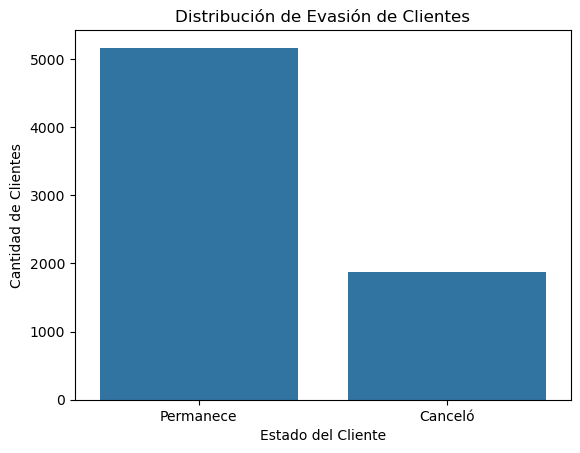

In [79]:
# Churn count
churn_counts = df_transformado['Churn'].value_counts()

plt.figure()
sns.barplot(x=churn_counts.index, y=churn_counts.values)

plt.xticks([0,1], ['Retained', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Number of Customers')
plt.title('Customer Churn Distribution')

plt.show()

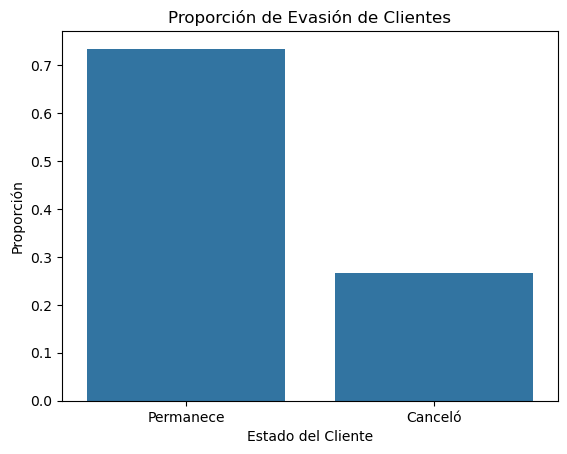

In [ ]:
# Churn proportion
churn_prop = df_transformado['Churn'].value_counts(normalize=True)

plt.figure()
sns.barplot(x=churn_prop.index, y=churn_prop.values)

plt.xticks([0,1], ['Retained', 'Churned'])
plt.xlabel('Customer Status')
plt.ylabel('Proportion')
plt.title('Customer Churn Proportion')

plt.show()

The churn proportion shows that approximately 27% of customers have canceled the service, while 73% remain active. This cancellation rate is significant and represents a major challenge for the company, justifying a deeper analysis of the factors associated with churn.

In [89]:
# Analyze the relationship between the type of contract and the cancellation rate (Churn) to identify patterns that indicate which types of contracts carry the highest risk of cancellation.
# 0: Retained, 1: Churned
churn_contract = pd.crosstab(
    df_transformado['Contract'],
    df_transformado['Churn'],
    normalize='index'
)
churn_contract

Churn,0.0,1.0
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887228,0.112772
Two year,0.971513,0.028487


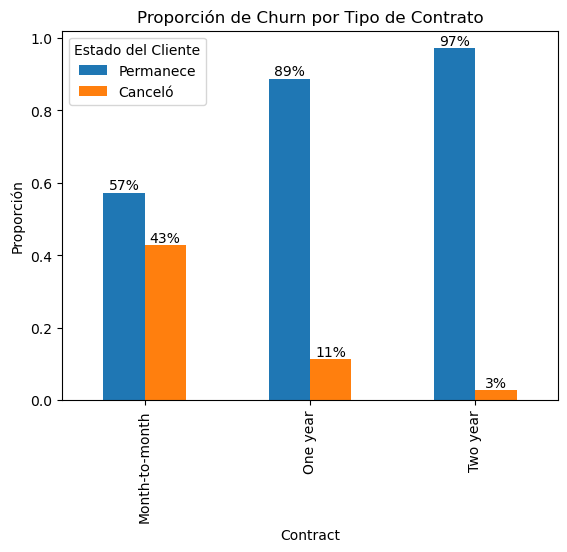

In [82]:
# Visualize the proportion of churn by contract type using a bar chart to visually identify which types of contracts have the highest risk of cancellation.
ax = churn_contract.plot(kind='bar')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0%}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom')

plt.ylabel('Proportion')
plt.title('Churn Proportion by Contract Type')
plt.legend(title='Customer Status')
plt.show()

It is observed that customers with month-to-month contracts have a considerably higher cancellation rate than those with one-year or two-year contracts. This suggests that contractual stability significantly influences customer retention.

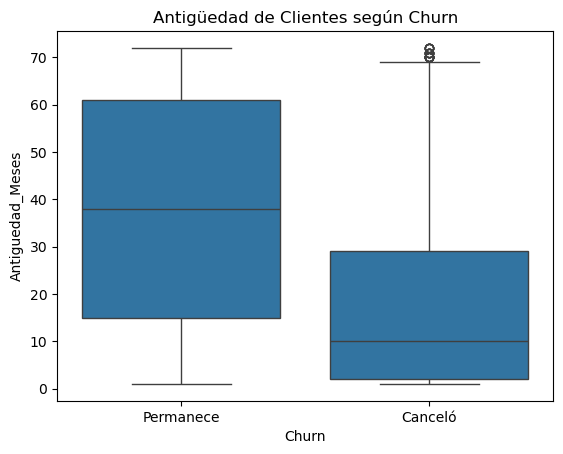

In [83]:
# We visualize the distribution of customer tenure according to their churn status using a boxplot to identify differences in tenure between retained and churned customers.
plt.figure()
sns.boxplot(x='Churn', y='Antiguedad_Meses', data=df_transformado)

plt.xticks([0,1], ['Retained', 'Churned'])
plt.title('Antigüedad de Clientes según Churn')
plt.show()

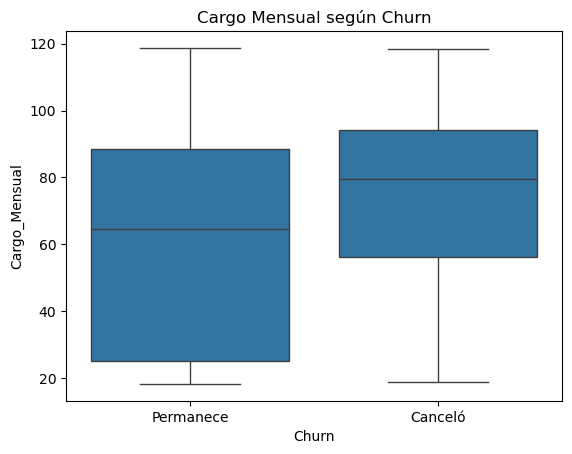

In [ ]:
# We visualize the monthly charge distribution of customers according to their churn status using a boxplot to identify differences in monthly charges between retained and churned customers.
plt.figure()
sns.boxplot(x='Churn', y='Cargo_Mensual', data=df_transformado)

plt.xticks([0,1], ['Retained', 'Churned'])
plt.title('Cargo Mensual según Churn')
plt.show()

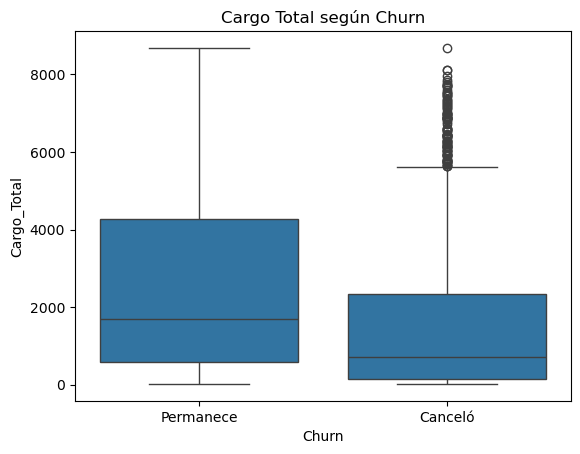

In [ ]:
# We visualize the accumulated total charge distribution of customers according to their churn status using a boxplot to identify differences in total charges between retained and churned customers.
plt.figure()
sns.boxplot(x='Churn', y='Cargo_Total', data=df_transformado)

plt.xticks([0,1], ['Retained', 'Churned'])
plt.title('Cargo Total según Churn')
plt.show()

It is observed that customers who churned have a significantly lower average tenure than those who are retained, which suggests the risk of churning is higher during the first few months of service.
Likewise, churned customers show a higher average monthly charge, which could indicate price sensitivity as a determining factor.

Extra 3:

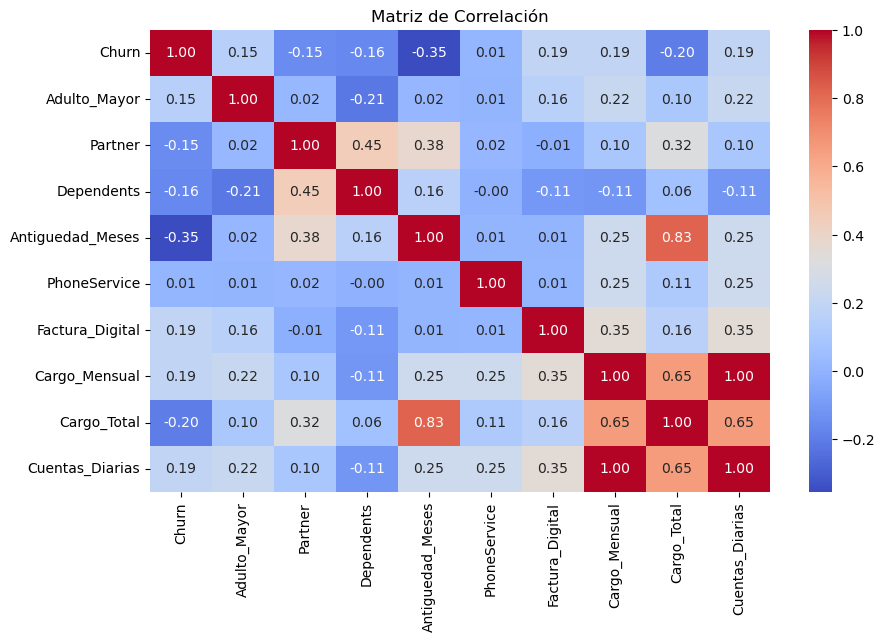

In [ ]:
# We analyze the correlation matrix between numerical variables to identify significant relationships that could influence churn, helping focus future analyses and predictive models on the most relevant variables.
plt.figure(figsize=(10,6))

corr = df_transformado.corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Matriz de Correlación")
plt.show()

In [87]:
corr_churn = df_transformado.corr(numeric_only=True)['Churn'].sort_values(ascending=False)
print(corr_churn)

Churn               1.000000
Cuentas_Diarias     0.192914
Cargo_Mensual       0.192858
Factura_Digital     0.191454
Adulto_Mayor        0.150541
PhoneService        0.011691
Partner            -0.149982
Dependents         -0.163128
Cargo_Total        -0.199484
Antiguedad_Meses   -0.354049
Name: Churn, dtype: float64


Correlation analysis indicates that customer tenure has the strongest negative relationship with churn, suggesting the cancellation risk decreases as the retention time increases. Furthermore, the monthly charge shows a moderate positive correlation with churn, which could indicate price sensitivity in certain segments.

# 📄Final Report – Customer Churn Analysis

### 1. Introduction:
This analysis aims to study customer churn in the company Telecom X, with the goal of identifying the factors that influence service cancellation.\
The company faces a significant customer attrition rate, which directly impacts its revenue and financial stability. Through exploratory data analysis (EDA), we seek to understand the patterns associated with churn and generate strategic insights to design more effective retention actions.


### 2. Data Cleaning and Processing

📌 Extraction and normalization.

Data was imported from a structured source with nested fields.\
pd.json_normalize() was used to flatten hierarchical columns.\
The information was consolidated into a single DataFrame for its analysis.


📌 Transformation\
Conversion of Charges.Total to numeric type.\
Binary encoding of the target variable Churn (0 = Retained, 1 = Churned).\
Conversion of binary variables (Partner, Dependents, PhoneService, etc.) to 0/1 format.\
Creation of the variable Cuentas_Diarias from the monthly charge.\
Standardization of column names to improve clarity.\
These actions ensured consistency, integrity, and suitability of the dataset for statistical analysis.

### 3. Exploratory Data Analysis (EDA)

📊 General Churn Distribution
The analysis showed that approximately 27% of the customers canceled the service, while 73% remain active.\
This churn rate is significant and justifies a deeper analysis of the associated factors.

### 4. Conclusions and Insights

From the analysis conducted, the following key findings emerged:\
The churn rate (~27%) is considerable and represents a risk for the company.\
Month-to-month contracts have the highest churn rate.\
Customer tenure is the most determining factor: the shorter the time with the company, the higher the cancellation probability.\
Customers with higher monthly charges show a greater tendency to cancel.\
Contractual stability and long-term retention are protective factors against churn.

### 5. Strategic Recommendations

Based on the findings obtained, the following actions are suggested:

🎯 1. Incentivize long-term contracts\
Offer discounts or benefits to customers with monthly contracts to migrate them to annual or biennial plans.\

🎯 2. Early retention strategies\
Implement follow-up campaigns during the customer's initial months, a stage where the churn risk is highest.\

🎯 3. Review pricing structure\
Evaluate value perception among customers with high monthly charges to reduce cancellations due to price sensitivity.\

🎯 4. Loyalty programs\
Develop progressive benefits based on tenure to increase customer commitment.

### Final Conclusion:

#### This exploratory analysis allowed us to identify clear patterns associated with customer churn. The results obtained can serve as a basis for the development of predictive churn models and the implementation of more efficient retention strategies at Telecom X.